In [26]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
df  = pd.read_csv('2024-05-29T16-50-30.088Z-canada_per_capita_income.csv')

In [28]:
df

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583
5,1975,5998.144346
6,1976,7062.131392
7,1977,7100.126170
8,1978,7247.967035
9,1979,7602.912681


In [29]:
df.shape

(47, 2)

In [30]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     47 non-null     int64  
 1   per capita income (US$)  47 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 884.0 bytes


In [31]:
df.describe()

,year,per capita income (US$)
count,47.000000,47.000000
mean,1993.000000,18920.137063
std,13.711309,12034.679438
min,1970.000000,3399.299037
25%,1981.500000,9526.914515
50%,1993.000000,16426.725480
75%,2004.500000,27458.601420
max,2016.000000,42676.468370


Text(0.5, 1.0, 'Scatter Plot of Students Years vs per capita income (US$)')

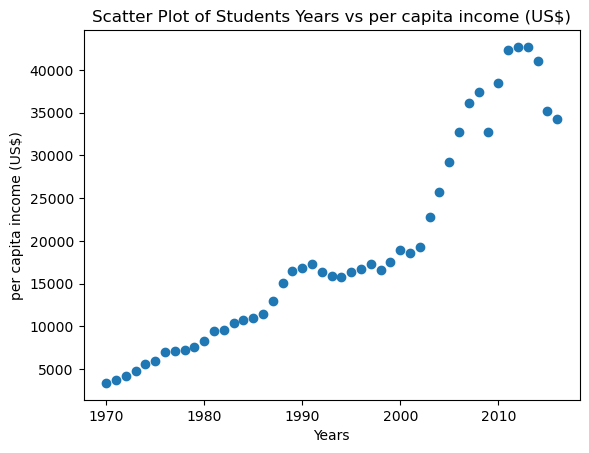

In [32]:
plt.scatter(df['year'], df['per capita income (US$)'])
plt.xlabel("Years")
plt.ylabel("per capita income (US$)")
plt.title("Scatter Plot of Students Years vs per capita income (US$)")

In [33]:
#split Dataset
X = df.drop("per capita income (US$)", axis = "columns")
y = df['per capita income (US$)']

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2) #, random_state=51

In [35]:
X_train

,year
1,1971
14,1984
32,2002
8,1978
20,1990
12,1982
43,2013
46,2016
39,2009
36,2006


In [36]:
X_test

,year
0,1970
17,1987
37,2007
34,2004
26,1996
24,1994
41,2011
9,1979
6,1976
42,2012


In [37]:
y_test

0      3399.299037
17    12974.806620
37    36144.481220
34    25719.147150
26    16699.826680
24    15755.820270
41    42334.711210
9      7602.912681
6      7062.131392
42    42665.255970
Name: per capita income (US$), dtype: float64

# Select a model and train it

In [38]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [39]:
lr.coef_

array([794.1854013])

In [40]:
lr.intercept_

-1564334.3923085346

In [41]:
lr.predict([[10]])

C:\Users\mahzu\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([-1556392.53829549])

In [42]:
m = 835.95541532
c = -1646897.994324619
z  = m * 10 + c 
z

-1638538.440171419

In [43]:
y_pred  = lr.predict(X_test)
y_pred

array([  210.84826076, 13712.00008293, 29595.70810901, 27213.1519051 ,
       20859.66869466, 19271.29789206, 32772.44971423,  7358.51687249,
        4975.96066858, 33566.63511553])

In [44]:
pd.DataFrame(np.c_[X_test, y_test, y_pred], columns = ["years", "per capita income (US$)","per capita income_predicted"])

,years,per capita income (US$),per capita income_predicted
0,1970.0,3399.299037,210.848261
1,1987.0,12974.806620,13712.000083
2,2007.0,36144.481220,29595.708109
3,2004.0,25719.147150,27213.151905
4,1996.0,16699.826680,20859.668695
5,1994.0,15755.820270,19271.297892
6,2011.0,42334.711210,32772.449714
7,1979.0,7602.912681,7358.516872
8,1976.0,7062.131392,4975.960669
9,2012.0,42665.255970,33566.635116


# Fine-tune your model

In [45]:
lr.score(X_test,y_test)

0.8659329584389635

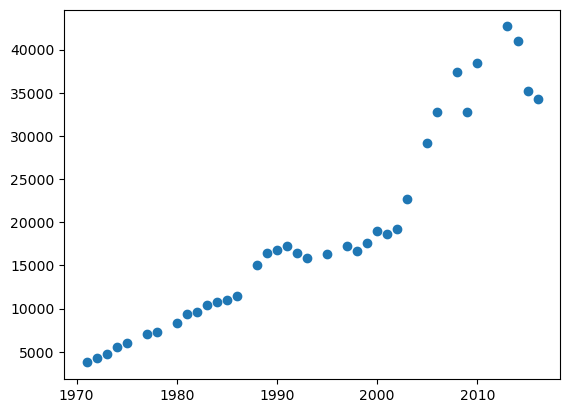

In [46]:
plt.scatter(X_train,y_train)  

In [47]:
lr.predict(X_train)

array([ 1005.03366206, 11329.44387901, 25624.78110249,  6564.33147119,
       16094.55628684,  9741.07307641, 34360.82051684, 36743.37672075,
       31184.07891162, 28801.52270771, 17682.92708945, 30389.89351032,
       12123.62928032, 21653.85409597, 14506.18548423,  3387.58986597,
       16888.74168814, 24830.59570119,  8152.7022738 ,  2593.40446467,
        5770.14606988, 35155.00591814, 28007.3373064 ,  8946.8876751 ,
        1799.21906336, 10535.25847771, 24036.41029988, 20065.48329336,
       31978.26431292, 22448.03949727, 12917.81468162, 18477.11249075,
       23242.22489858,  4181.77526728, 26418.96650379, 35949.19131944,
       15300.37088554])

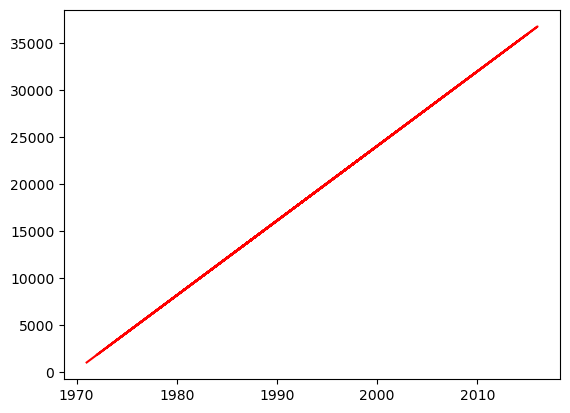

In [48]:
plt.plot(X_train, lr.predict(X_train), 'r-')

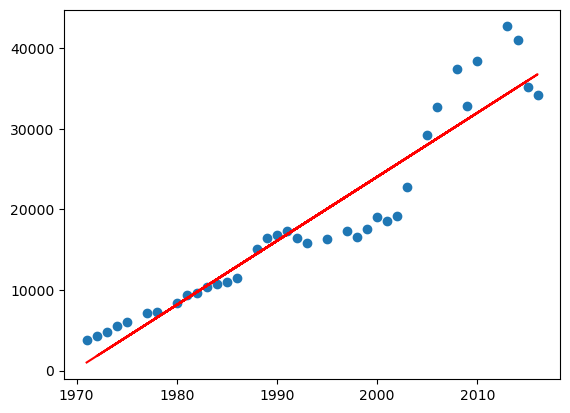

In [49]:
plt.scatter(X_train, y_train)
plt.plot(X_train, lr.predict(X_train), color = "r")

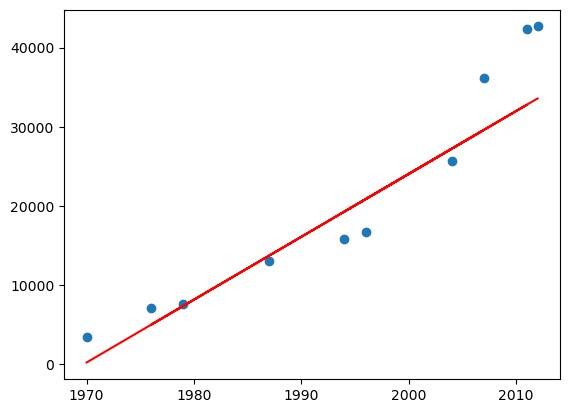

In [50]:
plt.scatter(X_test, y_test)
plt.plot(X_test, lr.predict(X_test), color = "r")

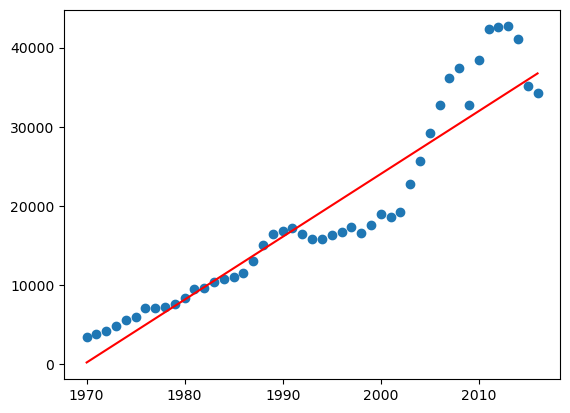

In [51]:
plt.scatter(X, y)
plt.plot(X, lr.predict(X), color = "r")